In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('placement_new.csv')

In [3]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [5]:
df.tail()

,cgpa,package
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96
199,6.22,2.33


In [6]:
df.size

400

In [7]:
df.shape

(200, 2)

In [8]:
x= df.drop('package',axis=1) 
y=df['package']
print('shape of x = ',x.shape)
print('shape of y = ',y.shape)

shape of x =  (200, 1)
shape of y =  (200,)


In [9]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=51)
print('shape of x_train = ',x_train.shape)
print('shape of y_train = ',y_train.shape)
print('shape of x_test = ',x_test.shape)
print('shape of y_test = ',y_test.shape)


shape of x_train =  (160, 1)
shape of y_train =  (160,)
shape of x_test =  (40, 1)
shape of y_test =  (40,)


In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
lr.score(x_test , y_test)

0.7108594076269938

In [13]:
x_pred=lr.predict(x_test)
print(x_pred)

[3.30991715 3.33827577 2.95259848 2.84483571 3.69559445 3.06036125
 3.21349783 2.94125503 2.52721911 3.16812403 2.52721911 2.03377904
 3.75231169 3.33260405 2.70871431 3.30424542 3.03767435 3.55947305
 3.51409925 3.40066475 2.18124389 4.44993386 3.4800689  3.61051857
 2.58393636 2.90155295 3.3439475  2.65766878 2.9128964  2.41378461
 2.95259848 2.70304258 2.76543156 2.15288526 3.08871988 2.62931016
 3.32693232 2.94692675 1.73317762 2.39109771]


In [14]:
lr.intercept_

-0.9835786249370262

Text(0, 0.5, 'package')

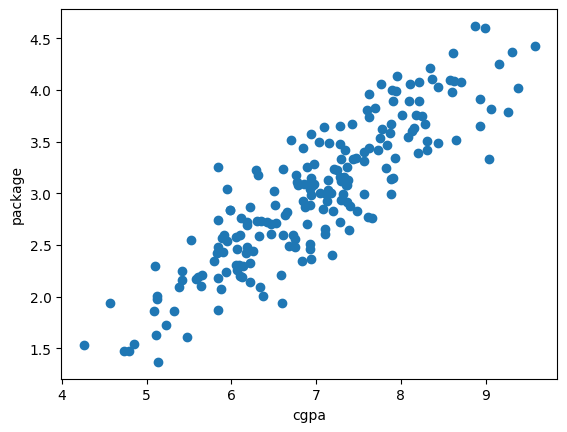

In [17]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')

Text(0, 0.5, 'package(in lpa)')

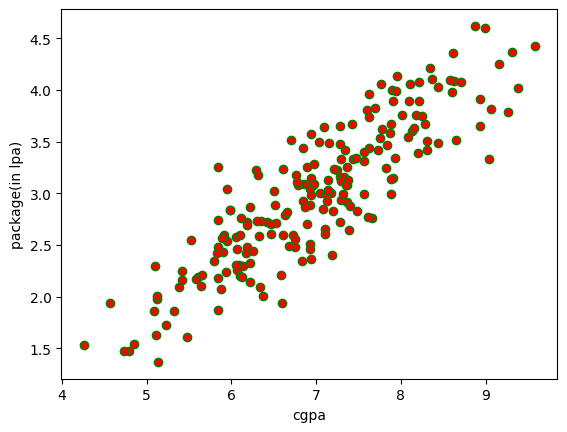

In [42]:
plt.scatter(df['cgpa'],df['package'],color="green",facecolor="red")
plt.xlabel('cgpa')
plt.ylabel('package(in lpa)')

In [25]:
m=lr.coef_
m

array([0.56717249])

In [26]:
b=lr.intercept_
b

-0.9835786249370262

In [28]:
#y = mx+b
m*8.58+b

array([3.88276137])

In [29]:
y_test.head()

148    3.40
104    3.74
4      3.57
7      2.48
192    3.75
Name: package, dtype: float64

In [34]:
x_test.head(4)

,cgpa
148,7.57
104,7.62
4,6.94
7,6.75


In [35]:
m*7.57+b

array([3.30991715])

In [37]:
x_test.iloc[0].values.reshape(1,1)

array([[7.57]])

In [39]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

C:\Users\Kiran Maske\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.30991715])

Text(0, 0.5, 'package(in lpa)')

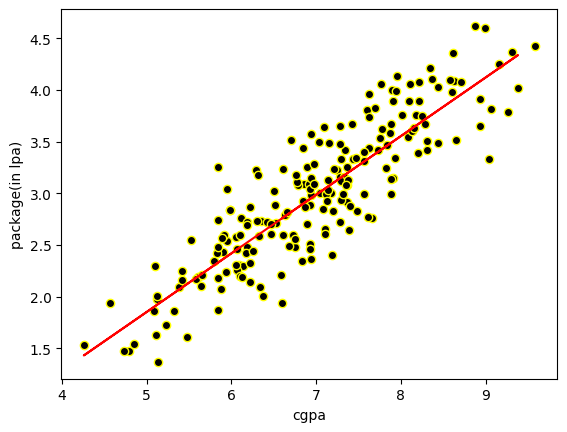

In [44]:
plt.scatter(df['cgpa'],df['package'],color="yellow",facecolor="black")
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('cgpa')
plt.ylabel('package(in lpa)')

In [46]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [47]:
y_pred=lr.predict(x_test)

In [48]:
y_test.values

array([3.4 , 3.74, 3.57, 2.48, 3.75, 2.93, 2.88, 3.09, 2.69, 2.99, 2.48,
       1.86, 4.21, 2.77, 2.89, 2.99, 3.64, 3.76, 3.34, 3.42, 2.17, 4.43,
       3.58, 3.89, 3.23, 2.93, 3.96, 2.72, 2.87, 2.84, 2.37, 3.02, 3.24,
       2.55, 3.  , 2.01, 3.81, 2.89, 1.48, 2.54])

In [50]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2717251868579489


In [51]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.11574657531303201


In [54]:
print("R2 Score",np.sqrt(r2_score(y_test,y_pred)))

R2 Score 0.8431247876957443


In [59]:
from sklearn.metrics import root_mean_squared_error

print("RMSE =", root_mean_squared_error(y_test, y_pred))

RMSE = 0.34021548364680876
